# 02.01 Random Assignment Mechanism and Experimental Unit
## Concept explanation

A/B Test 的随机分流不是一句“随机分成 A 组和 B 组”这么简单。核心问题是：我们到底把什么单位随机分到了 Control 或 Treatment？这个单位叫做 randomization unit，也可以叫 experimental unit。

常见实验单位包括：
| Randomization Unit | 含义                | 常见场景             | 风险                        |
| ------------------ | ----------------- | ---------------- | ------------------------- |
| user-level         | 以用户为单位分流          | 登录态产品、游戏、订阅、留存实验 | 需要稳定 user_id              |
| cookie-level       | 以浏览器 cookie 为单位分流 | 未登录网页、广告落地页      | 同一用户多个 cookie             |
| device-level       | 以设备为单位分流          | 移动 App、游戏设备号     | 同一用户多设备                   |
| session-level      | 以访问会话为单位分流        | 短期 UI、搜索排序、页面样式  | 同一用户多次进入不同组，容易有 carryover |


最重要的原则是：

实验单位决定独立样本，而不是数据表里的行数决定独立样本。如果是 user-level randomization，那么真正独立的是 users，而不是 events、clicks、sessions 或 page views。每次AB实验的样本量sample size是number of independent experimental units。如果是user-level randomization，那么sample size是number of users。

## 一个模拟例子

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
# 固定随机种子，保证结果可复现
rng = np.random.default_rng(42)

# 模拟用户数量
n_users = 8000

# 用户 ID
user_ids = np.arange(1, n_users+1)

# 按照用户维度进行随机分组
group = rng.choice(["control", "treatment"], size=n_users, p=[0.5, 0.5])

# 模拟用户活跃程度：不同用户天然活跃程度不同
activity = rng.lognormal(mean=1.1, sigma=0.8, size=n_users)

# 每个用户的 event 数量：活跃用户会产生更多 events
event_count = rng.poisson(lam=activity * 3) + 1

# Treatment 真实效果：让 Treatment 组略微提高转化概率
treatment_indicator = (group == "treatment").astype(int)

# 活跃程度标准化
activity_z = (np.log(activity) - np.log(activity).mean()) / np.log(activity).std()

# 用 logit 形式生成用户转化概率
## 这里activity_z代表了每个用户的个体特征因素
logit_p = -2.0 + 0.20 * activity_z + 0.12 * treatment_indicator
p_conversion = 1 / (1 + np.exp(-logit_p))

# 用户是否转化
converted = rng.binomial(n=1, p=p_conversion, size=n_users)

# user-level table
users = pd.DataFrame({
    "user_id": user_ids,
    "group": group,
    "activity": activity,
    "event_count": event_count,
    "converted": converted
})

users.head()

,user_id,group,activity,event_count,converted
0,1,treatment,1.095844,3,0
1,2,control,4.110815,10,0
2,3,treatment,3.291947,8,0
3,4,treatment,4.062124,16,0
4,5,control,4.380960,11,0


### 正确的分析维度

In [15]:
# 用户维度的分析
def mean_diff_analysis(df, group_col, value_col):
    """
    计算两组均值差、标准误、z值和双侧p-value。
    这里假设每一行是一个独立分析单位。
    """
    summary = (
        df.groupby(group_col)[value_col]
        .agg(["mean", "var", "count"])
        .rename(columns={"mean": "mean_value", "var": "sample_var", "count": "n"})
    )
    
    mean_t = summary.loc["treatment", "mean_value"]
    mean_c = summary.loc["control", "mean_value"]
    var_t = summary.loc["treatment", "sample_var"]
    var_c = summary.loc["control", "sample_var"]
    n_t = summary.loc["treatment", "n"]
    n_c = summary.loc["control", "n"]
    
    diff = mean_t - mean_c
    
    se = np.sqrt(var_t / n_t + var_c / n_c)
    
    z = diff / se
    
    p_value = 2 * stats.norm.sf(abs(z))
    
    return {
        "control_mean": mean_c,
        "treatment_mean": mean_t,
        "observed_lift": diff,
        "standard_error": se,
        "z_stat": z,
        "p_value": p_value,
        "control_n": n_c,
        "treatment_n": n_t
    }


user_level_result = mean_diff_analysis(
    df=users,
    group_col="group",
    value_col="converted"
)

user_level_result

{'control_mean': np.float64(0.1251545881770962),
 'treatment_mean': np.float64(0.12838008592367955),
 'observed_lift': np.float64(0.0032254977465833445),
 'standard_error': np.float64(0.007441377953218279),
 'z_stat': np.float64(0.43345436381018215),
 'p_value': np.float64(0.6646847132878652),
 'control_n': np.int64(4043),
 'treatment_n': np.int64(3957)}

### 错误的分析方式

In [18]:
# 将 user-level table 展开成 event-level table
events = users.loc[users.index.repeat(users["event_count"])].copy()

# 为每个用户内部生成 event 序号
events["event_index"] = events.groupby("user_id").cumcount() + 1

events = events[[
    "user_id",
    "event_index",
    "group",
    "converted",
    "activity",
    "event_count"
]]

events.head()

,user_id,event_index,group,converted,activity,event_count
0,1,1,treatment,0,1.095844,3
0,1,2,treatment,0,1.095844,3
0,1,3,treatment,0,1.095844,3
1,2,1,control,0,4.110815,10
1,2,2,control,0,4.110815,10


In [19]:
event_level_naive_result = mean_diff_analysis(
    df=events,
    group_col="group",
    value_col="converted"
)

event_level_naive_result

{'control_mean': np.float64(0.1470695039581669),
 'treatment_mean': np.float64(0.14574798024275376),
 'observed_lift': np.float64(-0.0013215237154131365),
 'standard_error': np.float64(0.0021589994570658587),
 'z_stat': np.float64(-0.6121000684312929),
 'p_value': np.float64(0.5404715522781963),
 'control_n': np.int64(55076),
 'treatment_n': np.int64(52234)}

### 两种分析方式的对比

In [20]:
comparison = pd.DataFrame([
    {
        "analysis_method": "Correct: user-level analysis",
        "sample_size_used": user_level_result["control_n"] + user_level_result["treatment_n"],
        "observed_lift": user_level_result["observed_lift"],
        "standard_error": user_level_result["standard_error"],
        "z_stat": user_level_result["z_stat"],
        "p_value": user_level_result["p_value"]
    },
    {
        "analysis_method": "Incorrect: naive event-level analysis",
        "sample_size_used": event_level_naive_result["control_n"] + event_level_naive_result["treatment_n"],
        "observed_lift": event_level_naive_result["observed_lift"],
        "standard_error": event_level_naive_result["standard_error"],
        "z_stat": event_level_naive_result["z_stat"],
        "p_value": event_level_naive_result["p_value"]
    }
])

comparison

,analysis_method,sample_size_used,observed_lift,standard_error,z_stat,p_value
0,Correct: user-level analysis,8000,0.003225,0.007441,0.433454,0.664685
1,Incorrect: naive event-level analysis,107310,-0.001322,0.002159,-0.612100,0.540472


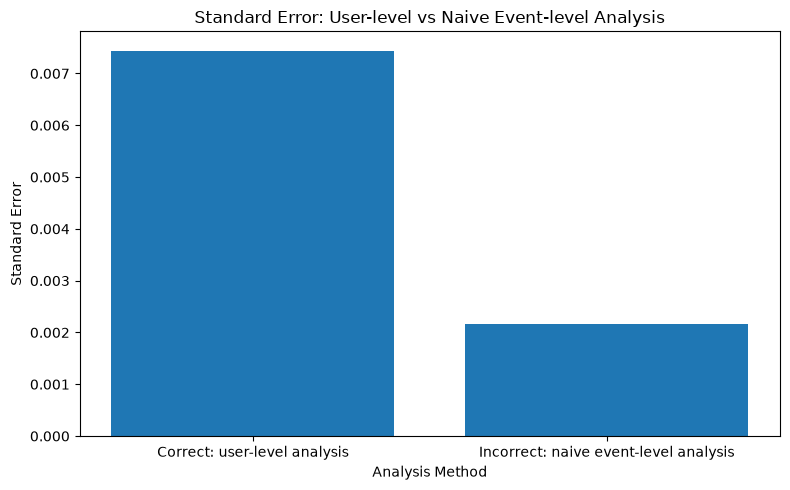

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    comparison["analysis_method"],
    comparison["standard_error"]
)

ax.set_title("Standard Error: User-level vs Naive Event-level Analysis")
ax.set_xlabel("Analysis Method")
ax.set_ylabel("Standard Error")

plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()

# 02.02 User-level Metric Construction